In [2]:
"""
PCA Analysis Script for Multiple Aligned CSV Files
This script reads multiple CSV files, merges them, excludes specified columns,
and performs PCA on the remaining features.
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
base_path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206"

file1 = f"{base_path}/all_metrics_for_76_90000_samples_animal_206.csv"
file2 = f"{base_path}/all_dynamic_metrics_for_76_90000_samples_animal_206_updated.csv"
file3 = f"{base_path}/all_static_metrics_for_76_90000_samples_animal_206_updated.csv"

# Columns to exclude
exclude_columns = [
    'eta', 'gamma', 'id', 
    'distance_relationship_type', 'preferential_relationship_type', 
    'generative_rule', 'num_iterations', 'network_index',
    'h_params_input_scaling', 'h_params_train_len', 'h_params_n_runs', 
    'h_params_n_lags', 'h_params_test_len', 'h_params_leak_rate', 
    'h_params_bias', 'h_params_n_transient', 'h_params_random_state'
]

# Read CSV files
print("Reading CSV files...")
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
df3 = pd.read_csv(file3)

print(f"File 1 shape: {df1.shape}")
print(f"File 2 shape: {df2.shape}")
print(f"File 3 shape: {df3.shape}")

# Merge dataframes on eta, gamma, id (assuming rows are aligned)
# Since rows are aligned, we can simply concatenate columns
# But let's merge to be safe
print("\nMerging dataframes...")
df_merged = df1.copy()

# Merge df2 (drop duplicate merge keys)
df2_features = df2.drop(columns=['eta', 'gamma', 'id'], errors='ignore')
df_merged = pd.concat([df_merged, df2_features], axis=1)

# Merge df3 (drop duplicate merge keys)
df3_features = df3.drop(columns=['eta', 'gamma', 'id'], errors='ignore')
df_merged = pd.concat([df_merged, df3_features], axis=1)

print(f"Merged dataframe shape: {df_merged.shape}")

# Get all column names
all_columns = df_merged.columns.tolist()

# Filter out excluded columns
feature_columns = [col for col in all_columns if col not in exclude_columns]

print(f"\nTotal columns: {len(all_columns)}")
print(f"Excluded columns: {len(exclude_columns)}")
print(f"Feature columns for PCA: {len(feature_columns)}")

# Extract features for PCA
X = df_merged[feature_columns].copy()

# Handle missing values
print(f"\nMissing values before handling: {X.isnull().sum().sum()}")
X = X.fillna(X.mean())  # Fill NaN with column mean
print(f"Missing values after handling: {X.isnull().sum().sum()}")

# Handle infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

# Drop columns that are all NaN (if any remain)
X = X.dropna(axis=1, how='all')

# Update feature_columns to match the cleaned data
feature_columns_cleaned = X.columns.tolist()

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Feature columns after cleaning: {len(feature_columns_cleaned)}")
if len(feature_columns_cleaned) != len(feature_columns):
    print(f"Note: {len(feature_columns) - len(feature_columns_cleaned)} columns were removed during cleaning")

# Standardize features
print("\nStandardizing features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
print("\nPerforming PCA...")
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNumber of components explaining 95% variance: {n_components_95}")
print(f"Total variance explained by first 10 components: {cumulative_variance[9]:.4f}")

# Create results dataframe
pca_results = pd.DataFrame(
    X_pca[:, :10],  # First 10 principal components
    columns=[f'PC{i+1}' for i in range(10)]
)

# Add back the identifying columns
pca_results['eta'] = df_merged['eta'].values
pca_results['gamma'] = df_merged['gamma'].values
pca_results['id'] = df_merged['id'].values

# Save PCA results
output_file = f"{base_path}/pca_results.csv"
pca_results.to_csv(output_file, index=False)
print(f"\nPCA results saved to: {output_file}")

# Save explained variance
variance_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Explained_Variance': explained_variance,
    'Cumulative_Variance': cumulative_variance
})
variance_file = f"{base_path}/pca_explained_variance.csv"
variance_df.to_csv(variance_file, index=False)
print(f"Explained variance saved to: {variance_file}")

# Create visualizations
print("\nCreating visualizations...")

# Figure 1: Scree plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot - explained variance
axes[0].bar(range(1, min(21, len(explained_variance)+1)), 
            explained_variance[:20], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Scree Plot - Explained Variance by Component', fontsize=14)
axes[0].grid(alpha=0.3)

# Cumulative variance plot
axes[1].plot(range(1, min(21, len(cumulative_variance)+1)), 
             cumulative_variance[:20], marker='o', color='darkred')
axes[1].axhline(y=0.95, color='green', linestyle='--', label='95% variance')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
scree_file = f"{base_path}/pca_scree_plot.png"
plt.savefig(scree_file, dpi=300, bbox_inches='tight')
print(f"Scree plot saved to: {scree_file}")
plt.close()

# Figure 2: PC1 vs PC2 scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=20)
ax.set_xlabel(f'PC1 ({explained_variance[0]:.2%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_variance[1]:.2%} variance)', fontsize=12)
ax.set_title('PCA: First Two Principal Components', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
scatter_file = f"{base_path}/pca_pc1_pc2_scatter.png"
plt.savefig(scatter_file, dpi=300, bbox_inches='tight')
print(f"PC1 vs PC2 scatter plot saved to: {scatter_file}")
plt.close()

# Figure 3: Loadings heatmap for top components
n_top_components = min(10, pca.components_.shape[0])
n_top_features = min(30, len(feature_columns))  # Top 30 features by loading magnitude

# Get top features by absolute loading on first PC
top_feature_indices = np.argsort(np.abs(pca.components_[0]))[-n_top_features:]
top_feature_names = [feature_columns_cleaned[i] for i in top_feature_indices]

loadings = pca.components_[:n_top_components, top_feature_indices].T

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(loadings, 
            xticklabels=[f'PC{i+1}' for i in range(n_top_components)],
            yticklabels=top_feature_names,
            cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Loading'},
            ax=ax)
ax.set_title(f'PCA Loadings - Top {n_top_features} Features by PC1 Magnitude', fontsize=14)
plt.tight_layout()
loadings_file = f"{base_path}/pca_loadings_heatmap.png"
plt.savefig(loadings_file, dpi=300, bbox_inches='tight')
print(f"Loadings heatmap saved to: {loadings_file}")
plt.close()

# Save full loadings matrix
loadings_full = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])],
    index=feature_columns_cleaned
)
loadings_full_file = f"{base_path}/pca_loadings_full.csv"
loadings_full.to_csv(loadings_full_file)
print(f"Full loadings matrix saved to: {loadings_full_file}")

print("\n" + "="*70)
print("PCA Analysis Complete!")
print("="*70)
print(f"\nSummary:")
print(f"  - Total samples: {X.shape[0]}")
print(f"  - Total features: {X.shape[1]}")
print(f"  - Components for 95% variance: {n_components_95}")
print(f"  - Variance explained by PC1: {explained_variance[0]:.2%}")
print(f"  - Variance explained by PC2: {explained_variance[1]:.2%}")
print(f"  - Variance explained by PC1-PC10: {cumulative_variance[9]:.2%}")
print("\nOutput files generated:")
print(f"  1. {output_file}")
print(f"  2. {variance_file}")
print(f"  3. {scree_file}")
print(f"  4. {scatter_file}")
print(f"  5. {loadings_file}")
print(f"  6. {loadings_full_file}")

Reading CSV files...
File 1 shape: (90000, 83)
File 2 shape: (90019, 15)
File 3 shape: (90019, 4)

Merging dataframes...
Merged dataframe shape: (90019, 96)

Total columns: 96
Excluded columns: 17
Feature columns for PCA: 79

Missing values before handling: 1273
Missing values after handling: 0

Final feature matrix shape: (90019, 81)
Feature columns after cleaning: 81
Note: -2 columns were removed during cleaning

Standardizing features...

Performing PCA...


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul


Number of components explaining 95% variance: 29
Total variance explained by first 10 components: 0.7353

PCA results saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/pca_results.csv
Explained variance saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/pca_explained_variance.csv

Creating visualizations...
Scree plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/pca_scree_plot.png
PC1 vs PC2 scatter plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/pca_pc1_pc2_scatter.png
Loadings heatmap saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/pca_loadings_heatmap.png
Full loadings matrix 

In [3]:
X.keys()

Index(['MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)',
       'avg_communicability', 'global_efficiency', 'modularity',
       'avg_clustering', 'avg_degree', 'density_bct', 'transitivity',
       'avg_edge_distance', 'wiring_cost', 'wiring_cost', 'char_path_length',
       'richclub_n_edges', 'richclub_avg_length', 'mc_mean', 'mc_std',
       'h_params_spectral_radius', 'mc_0', 'mc_1', 'mc_2', 'mc_3', 'mc_4',
       'mc_5', 'mc_6', 'mc_7', 'mc_8', 'mc_9', 'mc_10', 'mc_11', 'mc_12',
       'mc_13', 'mc_14', 'mc_15', 'mc_16', 'mc_17', 'mc_18', 'mc_19', 'mc_20',
       'mc_21', 'mc_22', 'mc_23', 'mc_24', 'mc_25', 'mc_26', 'mc_27', 'mc_28',
       'mc_29', 'mc_30', 'mc_31', 'mc_32', 'mc_33', 'mc_34', 'mc_35', 'mc_36',
       'mc_37', 'mc_38', 'mc_39', 'mc_40', 'mc_41', 'mc_42', 'mc_43', 'mc_44',
       'mc_45', 'mc_46', 'mc_47', 'mc_48', 'mc_49', 'nct_control_avg',
       'nct_control_std', 'nct_control_max', 'nct_control_n_nodes_90_percent',
       'nct_control_n_node

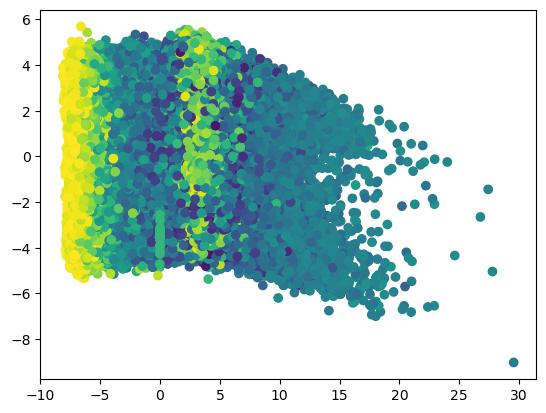

In [4]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=X["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"])

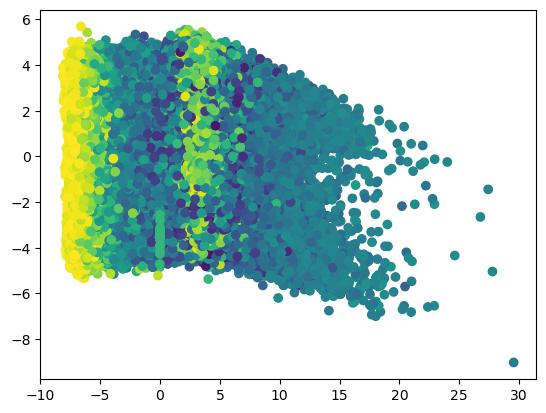

In [5]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=X["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"])

In [6]:
X.keys()

Index(['MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)',
       'avg_communicability', 'global_efficiency', 'modularity',
       'avg_clustering', 'avg_degree', 'density_bct', 'transitivity',
       'avg_edge_distance', 'wiring_cost', 'wiring_cost', 'char_path_length',
       'richclub_n_edges', 'richclub_avg_length', 'mc_mean', 'mc_std',
       'h_params_spectral_radius', 'mc_0', 'mc_1', 'mc_2', 'mc_3', 'mc_4',
       'mc_5', 'mc_6', 'mc_7', 'mc_8', 'mc_9', 'mc_10', 'mc_11', 'mc_12',
       'mc_13', 'mc_14', 'mc_15', 'mc_16', 'mc_17', 'mc_18', 'mc_19', 'mc_20',
       'mc_21', 'mc_22', 'mc_23', 'mc_24', 'mc_25', 'mc_26', 'mc_27', 'mc_28',
       'mc_29', 'mc_30', 'mc_31', 'mc_32', 'mc_33', 'mc_34', 'mc_35', 'mc_36',
       'mc_37', 'mc_38', 'mc_39', 'mc_40', 'mc_41', 'mc_42', 'mc_43', 'mc_44',
       'mc_45', 'mc_46', 'mc_47', 'mc_48', 'mc_49', 'nct_control_avg',
       'nct_control_std', 'nct_control_max', 'nct_control_n_nodes_90_percent',
       'nct_control_n_node

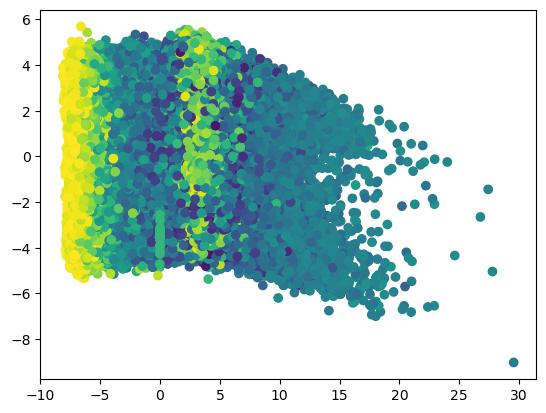

In [7]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=X["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"])

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_14108/362868591.py:11: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


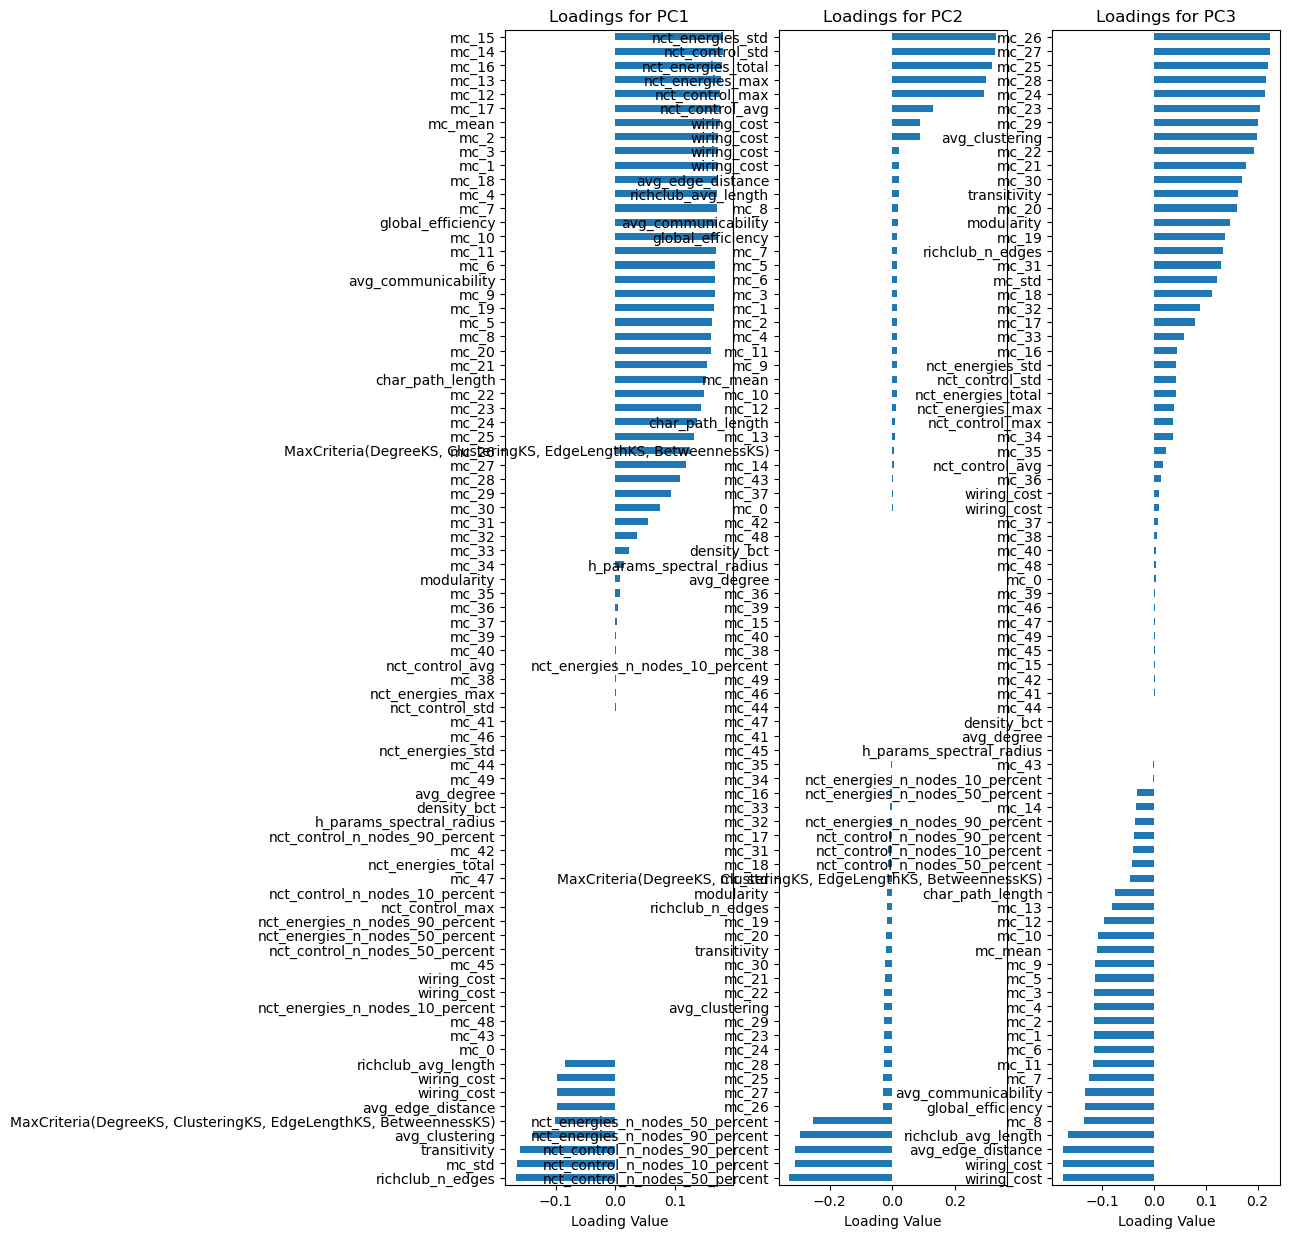

In [10]:
loadings_full

# create loading barplots (3x1) for first 3 PCs
num_pcs_to_plot = 3
fig, axes = plt.subplots(1, num_pcs_to_plot, figsize=(10, 5 * num_pcs_to_plot))
for i in range(num_pcs_to_plot):
    pc_loadings = loadings_full[f'PC{i+1}']
    pc_loadings.sort_values().plot(kind='barh', ax=axes[i])
    axes[i].set_title(f'Loadings for PC{i+1}')
    axes[i].set_xlabel('Loading Value')
plt.tight_layout()

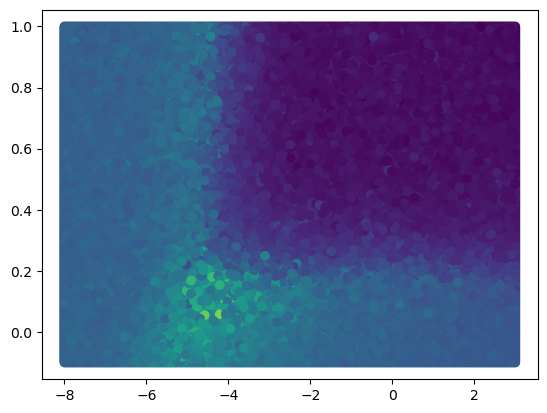

In [15]:
plt.scatter(df_merged["eta"], df_merged["gamma"], c=X_pca[:, 0])

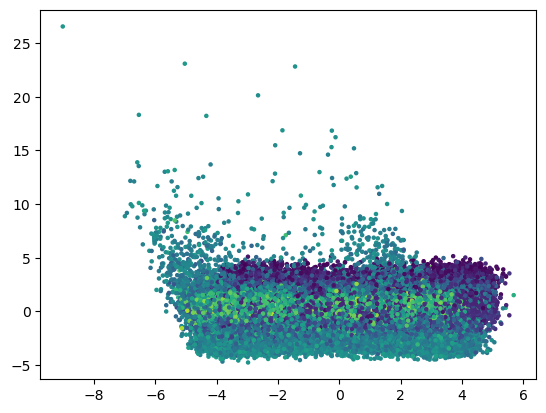

In [24]:
plt.scatter(X_pca[:, 1], X_pca[:, 3], s=5, c=df_merged["avg_clustering"]) # nct_energies_std"])

In [11]:
df_merged


,eta,gamma,id,distance_relationship_type,preferential_relationship_type,generative_rule,num_iterations,"MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)",network_index,avg_communicability,...,nct_control_n_nodes_90_percent,nct_control_n_nodes_50_percent,nct_control_n_nodes_10_percent,nct_energies_total,nct_energies_std,nct_energies_max,nct_energies_n_nodes_90_percent,nct_energies_n_nodes_50_percent,nct_energies_n_nodes_10_percent,wiring_cost
0,-1.488294,0.028763,0.0,powerlaw,powerlaw,MatchingIndex,495.0,0.690000,0.0,0.014577,...,89.0,48.0,9.0,30576.600715,316.229504,1262.109608,52.0,17.0,2.0,3.715241
1,2.558528,0.462876,0.0,powerlaw,powerlaw,MatchingIndex,495.0,0.900000,0.0,0.006016,...,89.0,48.0,9.0,30493.111829,303.326504,1406.666298,54.0,18.0,2.0,3.731678
2,2.264214,0.444482,0.0,powerlaw,powerlaw,MatchingIndex,495.0,0.790000,0.0,0.006498,...,89.0,48.0,9.0,26612.892640,263.446982,1314.816981,56.0,18.0,2.0,3.720429
3,2.337793,0.793980,0.0,powerlaw,powerlaw,MatchingIndex,495.0,0.940000,0.0,0.005567,...,89.0,48.0,9.0,26902.299303,268.043094,1142.035862,53.0,18.0,2.0,3.711998
4,2.337793,0.282609,0.0,powerlaw,powerlaw,MatchingIndex,495.0,0.553535,0.0,0.009031,...,89.0,48.0,9.0,27489.422867,259.376938,1258.414002,55.0,19.0,2.0,3.679677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,89.0,48.0,9.0,25149.983419,249.029496,1066.705946,54.0,18.0,2.0,3.703460
90015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,89.0,48.0,9.0,30301.239225,309.871407,1516.891726,54.0,18.0,2.0,3.702856
90016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,89.0,48.0,9.0,26315.426223,272.400976,1167.689590,51.0,17.0,2.0,3.732706
90017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,89.0,48.0,8.0,26387.083221,264.057889,1342.732844,55.0,18.0,2.0,3.734971


In [ ]:
from sklearn.manifold import TSNE
import umap

# Run t-SNE and UMAP on the same X_scaled data used for PCA
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# Color by PC1 score
color_values = X_pca[:, 0]

fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((12, 6)), dpi=150)

cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
    'custom_bw', ["black", bone_white])

# t-SNE
sc0 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=color_values, cmap=cmap,
                       s=1, alpha=0.5, rasterized=True)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].text(0.05, 0.95, 't-SNE', transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=halfblack, alpha=0.8))

# UMAP
sc1 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=color_values, cmap=cmap,
                       s=1, alpha=0.5, rasterized=True)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].text(0.05, 0.95, 'UMAP', transform=axes[1].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=halfblack, alpha=0.8))

plt.tight_layout()
plt.savefig(output_path / 'tsne_umap_colored_by_pc1.pdf', bbox_inches='tight')
plt.show()